In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
def simulate_bb84_full(N, p_relax, p_dephase, p_readout):
    # Generate Alice bits and bases
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    
    # Generate Bob bases
    bob_bases = np.random.randint(0, 2, N)
    
    # Apply noise (Relaxation & Dephasing)
    noisy_bits = []
    for bit, basis in zip(alice_bits, alice_bases):
        current_bit = bit
        
        # 1. Relaxation (T1 error) - mostly flips 1 to 0
        if current_bit == 1:
            if np.random.random() < p_relax:
                current_bit = 0
                
        # 2. Dephasing (T2 error) - phase flip affects X basis (basis=1)
        if basis == 1:
            if np.random.random() < p_dephase:
                current_bit = 1 - current_bit
                
        noisy_bits.append(current_bit)
    noisy_bits = np.array(noisy_bits)
    
    # Measure and apply Readout Error
    bob_results = []
    for noisy_bit, a_basis, b_basis in zip(noisy_bits, alice_bases, bob_bases):
        if a_basis == b_basis:
            measured_bit = noisy_bit
        else:
            measured_bit = np.random.randint(0, 2)
            
        # 3. Readout error - hardware measurement error
        if np.random.random() < p_readout:
            measured_bit = 1 - measured_bit
            
        bob_results.append(measured_bit)
        
    # Sift
    sifted_alice = []
    sifted_bob = []
    for i in range(N):
        if alice_bases[i] == bob_bases[i]:
            sifted_alice.append(int(alice_bits[i]))
            sifted_bob.append(int(bob_results[i]))
            
    # Compute QBER
    errors = 0
    for a, b in zip(sifted_alice, sifted_bob):
        if a != b:
            errors += 1
            
    qber = errors / len(sifted_alice) if len(sifted_alice) > 0 else 0
    
    return {
        "qber": qber,
        "errors": errors,
        "sifted_length": len(sifted_alice)
    }


In [3]:
# Test the simulator with all 3 errors
qber_dict = simulate_bb84_full(
    N=1000,
    p_relax=0.05,
    p_dephase=0.05,
    p_readout=0.01
)

print("Test run results:", qber_dict)


Test run results: {'qber': 0.048484848484848485, 'errors': 24, 'sifted_length': 495}


In [4]:
results = []

# Generate a dataset using random sampling of the 3 parameters for ML
num_samples = 1000

for _ in range(num_samples):
    p_relax = np.random.uniform(0.0, 0.3)
    p_dephase = np.random.uniform(0.0, 0.3)
    p_readout = np.random.uniform(0.0, 0.1)
    
    qbers = []
    # Run BB84 10 times to get a stable average QBER for these parameters
    for _ in range(10):
        res = simulate_bb84_full(N=1000, p_relax=p_relax, p_dephase=p_dephase, p_readout=p_readout)
        qbers.append(res['qber'])
    
    avg_qber = np.mean(qbers)
    results.append({
        'p_relax': p_relax,
        'p_dephase': p_dephase,
        'p_readout': p_readout,
        'avg_qber': avg_qber
    })


In [5]:
df_full = pd.DataFrame(results)
df_full.head(10)


,p_relax,p_dephase,p_readout,avg_qber
0,0.037941,0.165813,0.094345,0.170655
1,0.010223,0.273344,0.096096,0.203792
2,0.131372,0.114393,0.039182,0.149298
3,0.133992,0.078695,0.032035,0.130858
4,0.153622,0.219812,0.090797,0.227924
5,0.143278,0.270012,0.021203,0.197677
6,0.265024,0.285194,0.003579,0.245393
7,0.067390,0.114937,0.095934,0.175614
8,0.123527,0.001467,0.032571,0.094119
9,0.066081,0.111659,0.080590,0.152817


In [6]:
os.makedirs("../data", exist_ok=True)
df_full.to_csv(
    "../data/qber_dataset_full.csv",
    index=False
)
print("Saved full dataset to ../data/qber_dataset_full.csv")


Saved full dataset to ../data/qber_dataset_full.csv


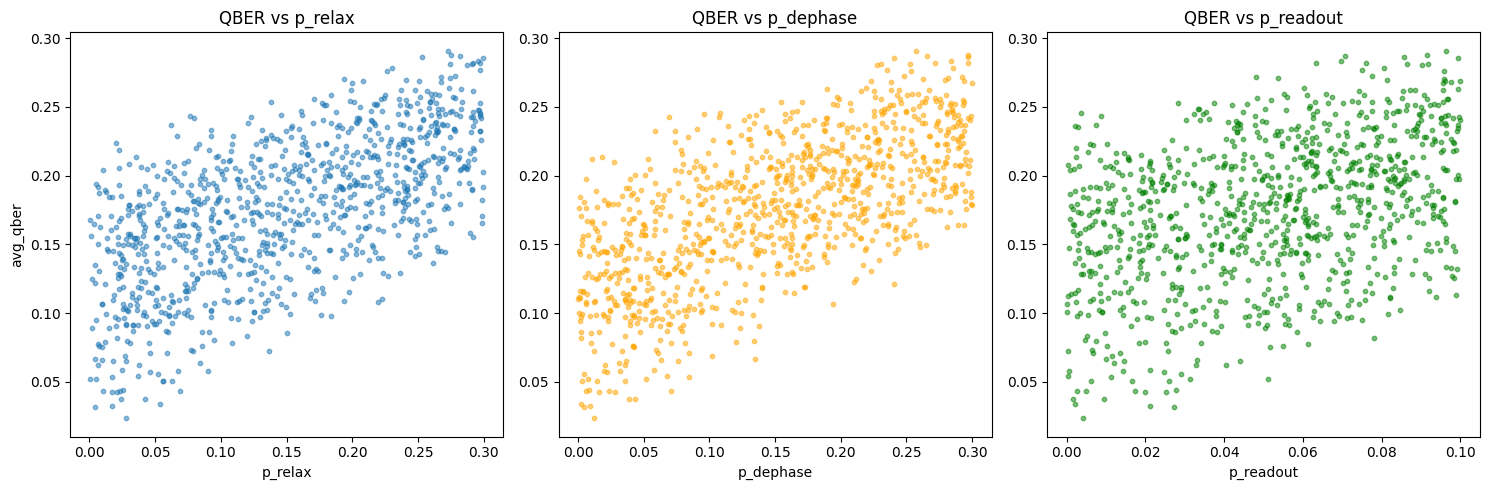

In [7]:
# Plotting the marginal relationship of each error vs QBER
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df_full['p_relax'], df_full['avg_qber'], alpha=0.5, s=10)
axes[0].set_title('QBER vs p_relax')
axes[0].set_xlabel('p_relax')
axes[0].set_ylabel('avg_qber')

axes[1].scatter(df_full['p_dephase'], df_full['avg_qber'], alpha=0.5, s=10, color='orange')
axes[1].set_title('QBER vs p_dephase')
axes[1].set_xlabel('p_dephase')

axes[2].scatter(df_full['p_readout'], df_full['avg_qber'], alpha=0.5, s=10, color='green')
axes[2].set_title('QBER vs p_readout')
axes[2].set_xlabel('p_readout')

plt.tight_layout()
plt.show()
